In [12]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.tensorboard import SummaryWriter
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, mean_squared_error
from f3_transforms import FaceDataset, show_image_with_landmarks, FaceDataset_2
from f4_model import Face_v1, Face_v2, initialize_model, train_model, compute_metrics, Face_v3

from torch.utils.data import Dataset, DataLoader, Subset


import matplotlib.pyplot as plt
import seaborn as sns
import cv2



### df

In [2]:
df = pd.read_pickle('./raf_slightly_mod.pkl')
df.head()

,image,emotion,race,age,gender,landmarks_manual,bbox,image_path
0,train_00001.jpg,3,0,2,1,"[[270.17, 330.696], [374.086, 302.67], [325.06...","[213.92009, 199.133484, 484.330719, 526.302246]",./RAF/Images/original/train_00001.jpg
1,train_00002.jpg,3,0,2,1,"[[532.365, 573.652], [753.071, 574.156], [604....","[407.148193, 265.544525, 912.439697, 1029.660645]",./RAF/Images/original/train_00002.jpg
2,train_00003.jpg,2,2,2,1,"[[463.469, 554.446], [596.902, 515.023], [472....","[418.01532, 345.02063, 772.46106, 872.50293]",./RAF/Images/original/train_00003.jpg
3,train_00004.jpg,2,0,2,1,"[[296.59, 316.573], [422.501, 318.766], [343.1...","[241.747635, 167.216034, 511.343781, 525.823669]",./RAF/Images/original/train_00004.jpg
4,train_00005.jpg,3,2,1,1,"[[161.18, 181.754], [221.991, 174.016], [201.8...","[114.065239, 113.609695, 249.960373, 281.496063]",./RAF/Images/original/train_00005.jpg


In [3]:
#train and test split count
train_count = df['image'].str.startswith('train').sum()
test_count = df['image'].str.startswith('test').sum()
train_count, test_count

(np.int64(12271), np.int64(3068))

In [4]:
import numpy as np

def create_data_loaders(df, dataset_class, image_size=128, val_ratio=0.1, batch_size=32, num_workers=4, seed=12):
    train_df = df[df['image_path'].str.contains('train')].reset_index(drop=True)
    test_df  = df[df['image_path'].str.contains('test')].reset_index(drop=True)
    
    full_train_dataset = dataset_class(train_df, image_size=image_size, training=True)
    test_dataset = dataset_class(test_df, image_size=image_size, training=False)
    
    num_val = int(len(full_train_dataset) * val_ratio)
    num_train = len(full_train_dataset) - num_val
    
    generator = torch.Generator().manual_seed(seed)
    train_dataset, val_dataset = torch.utils.data.random_split(full_train_dataset, [num_train, num_val], generator=generator)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    
    return train_loader, val_loader, test_loader


In [5]:
train_loader, val_loader, test_loader = create_data_loaders(
    df, dataset_class=FaceDataset, image_size=128, val_ratio=0.1, batch_size=32
)


### model

In [6]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

Using device: cuda


#### att1

In [27]:

model, optimizer = initialize_model(Face_v2, device=device, lr=1e-3)


In [8]:
def compute_class_weights(train_df, column_name):
    counts = train_df[column_name].value_counts().sort_index().values
    weights = sum(counts) / counts
    return torch.tensor(weights, dtype=torch.float)

In [10]:
train_df = df[df['image_path'].str.contains('train')].reset_index(drop=True)

In [11]:
emotion_weights = compute_class_weights(train_df, 'emotion').to(device)
race_weights    = compute_class_weights(train_df, 'race').to(device)
gender_weights  = compute_class_weights(train_df, 'gender').to(device)
age_weights     = compute_class_weights(train_df, 'age').to(device)
losses = {
    'landmarks': nn.MSELoss(),  # regression, unweighted
    'emotion': nn.CrossEntropyLoss(weight=emotion_weights),
    'race': nn.CrossEntropyLoss(weight=race_weights),
    'gender': nn.CrossEntropyLoss(weight=gender_weights),
    'age': nn.CrossEntropyLoss(weight=age_weights)
}

In [31]:
hist1 = train_model(
    model, {'train': train_loader, 'val': val_loader},
    optimizer, losses, name='face_multitask_att3',
    device=device,
    num_epochs=30)

Epoch 1/30


train: 100%|██████████| 346/346 [00:54<00:00,  6.30it/s]


train Losses: landmarks: 0.0324, emotion: 1.5872, race: 1.0216, gender: 1.0230, age: 1.5007


val: 100%|██████████| 39/39 [00:22<00:00,  1.77it/s]


val Losses: landmarks: 0.0263, emotion: 1.6044, race: 1.0708, gender: 0.9476, age: 1.4525
Epoch 2/30


...

val Losses: landmarks: 0.0196, emotion: 0.8814, race: 0.6098, gender: 0.5391, age: 1.1050
Epoch 30/30


train: 100%|██████████| 346/346 [00:36<00:00,  9.48it/s]


train Losses: landmarks: 0.0187, emotion: 0.6817, race: 0.4954, gender: 0.4340, age: 0.6434


val: 100%|██████████| 39/39 [00:20<00:00,  1.89it/s]

val Losses: landmarks: 0.0188, emotion: 0.8671, race: 0.5509, gender: 0.4612, age: 0.7252


##### etc

In [32]:
torch.save(model, 'face_v2_a3.pth')

In [53]:
model = torch.load('face_v2_a3.pth', map_location=device, weights_only=False)

In [7]:
def evaluate_model(model, data_loader, device='cuda'):
    model.eval()
    keys = ['landmarks', 'emotion', 'race', 'gender', 'age']
    
    all_predictions = {k: [] for k in keys}
    all_targets = {k: [] for k in keys}
    
    with torch.no_grad():
        for images, targets in data_loader:
            images = images.to(device)
            
            # Forward pass
            outputs = model(images)
            
            # Ensure outputs is a tuple/list
            if not isinstance(outputs, (tuple, list)):
                raise ValueError("Model must return a tuple/list matching keys order")
            
            for i, key in enumerate(keys):
                pred = outputs[i].cpu()
                # print(f'Key: {key}, pred shape: {pred.shape}')
                # print(f'Target shape: {targets[key].shape}')
                # For landmarks, flatten if needed
                if key == 'landmarks' and pred.ndim == 3:  # [B,5,2]
                    pred = pred.view(pred.size(0), -1)
                
                # print(f'After flattening, target shape: {target_flat.shape}')
                all_predictions[key].append(pred)
                all_targets[key].append(targets[key].cpu())
    
    # Concatenate all batches
    for k in keys:
        all_predictions[k] = torch.cat(all_predictions[k], dim=0)
        all_targets[k] = torch.cat(all_targets[k], dim=0)
    
    return all_predictions, all_targets

##### eval

In [61]:
predictions, target = evaluate_model(model, test_loader, device)

In [62]:
eval_metrics = compute_metrics(predictions, target)
print(eval_metrics)

emotion - y_pred shape: (3068,), y_true shape: (3068,)
race - y_pred shape: (3068,), y_true shape: (3068,)
gender - y_pred shape: (3068,), y_true shape: (3068,)
age - y_pred shape: (3068,), y_true shape: (3068,)
{'landmarks_mse': np.float32(0.021709183), 'emotion_acc': 0.7017601043024772, 'emotion_f1': np.float64(0.7088694806247182), 'emotion_precision': np.float64(0.7389496975780159), 'emotion_recall': np.float64(0.7017601043024772), 'emotion_confusion_matrix': array([[287,   7,   2,  15,  18],
       [ 37, 106,  11,  34,  46],
       [ 57,  37, 869,  81, 141],
       [ 47,  89,  21, 374, 109],
       [ 78,  31,   8,  46, 517]]), 'race_acc': 0.7480443285528031, 'race_f1': np.float64(0.7717235349139528), 'race_precision': np.float64(0.8316410550964494), 'race_recall': np.float64(0.7480443285528031), 'race_confusion_matrix': array([[1763,   93,  495],
       [  25,  163,   46],
       [  73,   41,  369]]), 'gender_acc': 0.7832464146023468, 'gender_f1': np.float64(0.7938695256223555), 'g

landmarks_mse: 0.0217
emotion_acc: 0.7018
emotion_f1: 0.7089
emotion_precision: 0.7389
emotion_recall: 0.7018
race_acc: 0.7480
race_f1: 0.7717
race_precision: 0.8316
race_recall: 0.7480
gender_acc: 0.7832
gender_f1: 0.7939
gender_precision: 0.8260
gender_recall: 0.7832
age_acc: 0.6369
age_f1: 0.6513
age_precision: 0.6949
age_recall: 0.6369


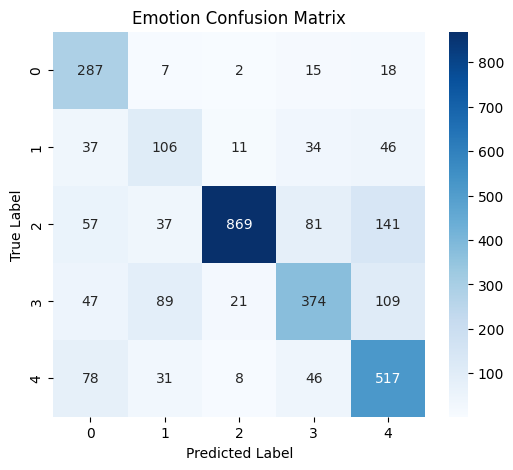

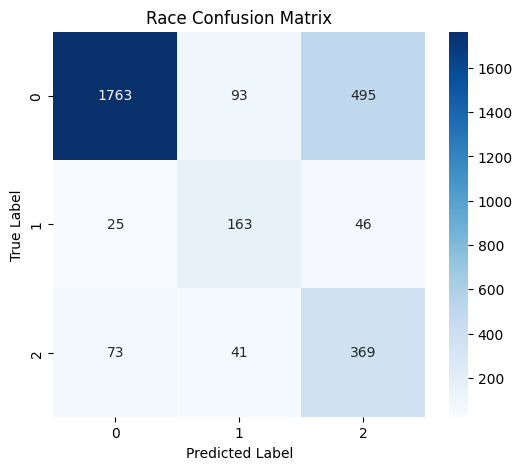

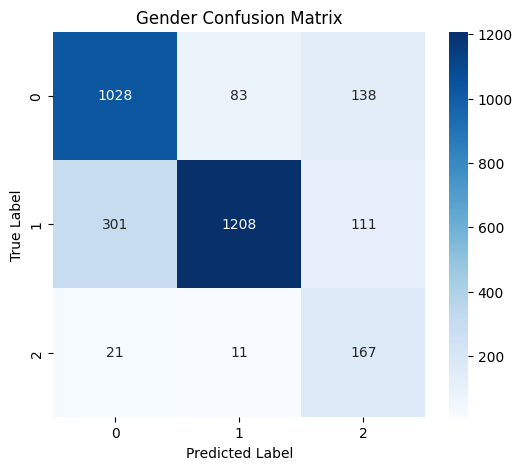

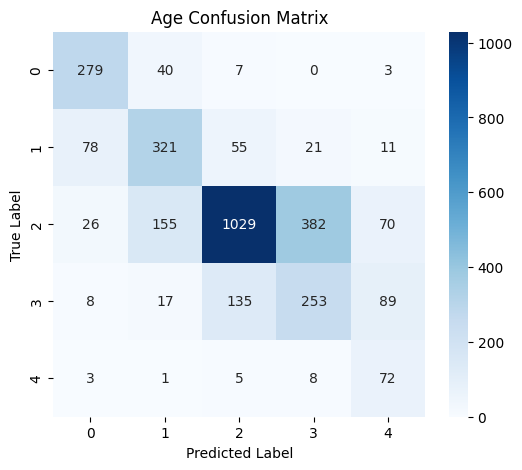

In [63]:
for key, value in eval_metrics.items():
    if not key.endswith('_confusion_matrix'):
        print(f"{key}: {value:.4f}" if isinstance(value, (float, np.floating)) else f"{key}: {value}")

# --- Plot confusion matrices ---
for task in ['emotion', 'race', 'gender', 'age']:
    cm = eval_metrics[f'{task}_confusion_matrix']
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{task.capitalize()} Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

In [34]:
def show_batch_images_with_landmarks(loader, model, device='cuda', num_images=5, figsize=(4, 4)):
    model.eval()

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            
            # Predicted landmarks (assumed to be the first output)
            pred_landmarks = outputs[0].cpu().numpy()  # [B, 10] or [B, 5, 2]
            
            # Reshape if necessary
            if pred_landmarks.ndim == 2 and pred_landmarks.shape[1] == 10:
                pred_landmarks = pred_landmarks.reshape(-1, 5, 2)
            elif pred_landmarks.ndim == 3:
                pass
            else:
                raise ValueError(f"Unexpected landmarks output shape: {pred_landmarks.shape}")
            
            gt_landmarks = labels['landmarks'].numpy()  # [B, 5, 2]
            
            batch_size = images.size(0)
            num_to_show = min(num_images, batch_size)

            for i in range(num_to_show):
                img = images[i].cpu().permute(1, 2, 0).numpy()
                img = (img * 255).astype('uint8')
                h, w, _ = img.shape

                # Scale normalized landmarks back to pixel coordinates
                gt_pts = gt_landmarks[i] * [w, h]
                pred_pts = pred_landmarks[i] * [w, h]

                img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

                # Draw GT landmarks (blue)
                for (x, y) in gt_pts:
                    cv2.circle(img_bgr, (int(x), int(y)), 3, (0, 0, 255), -1)

                # Draw predicted landmarks (red)
                for (x, y) in pred_pts:
                    cv2.circle(img_bgr, (int(x), int(y)), 3, (255, 0, 0), -1)

                emotion = labels['emotion'][i].item()
                race = labels['race'][i].item()
                gender = labels['gender'][i].item()
                age = labels['age'][i].item()

                plt.figure(figsize=figsize)
                plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
                plt.title(f"Emotion: {emotion}, Race: {race}, Gender: {gender}, Age: {age}")
                plt.axis('off')
                plt.show()
            break  # only first batch


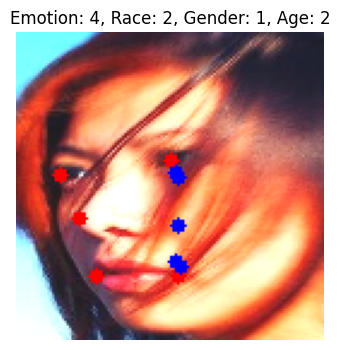

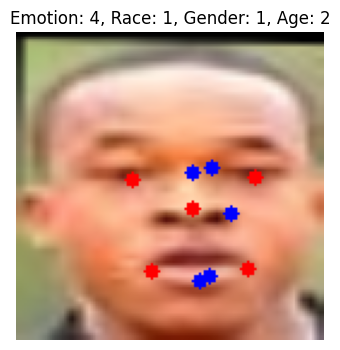

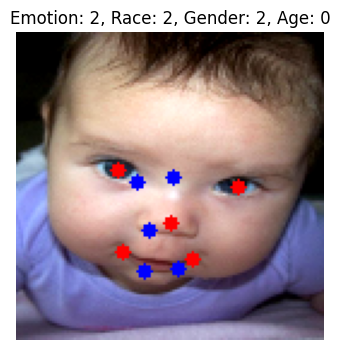

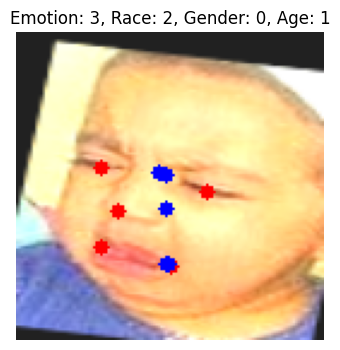

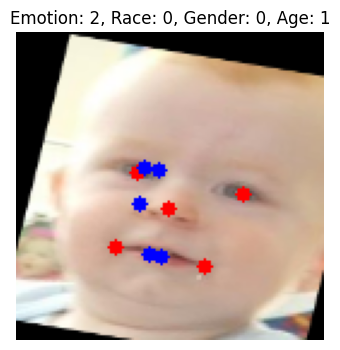

In [65]:
show_batch_images_with_landmarks(val_loader, model, device=device, num_images=5, figsize=(4, 4))

#### att2

In [25]:
train_loader, val_loader, test_loader = create_data_loaders(
    df, dataset_class=FaceDataset_2, image_size=128, val_ratio=0.1, batch_size=32
)


In [26]:

model, optimizer = initialize_model(Face_v3, device=device, lr=1e-3)


In [27]:
emotion_weights = compute_class_weights(train_df, 'emotion').to(device)
race_weights    = compute_class_weights(train_df, 'race').to(device)
gender_weights  = compute_class_weights(train_df, 'gender').to(device)
age_weights     = compute_class_weights(train_df, 'age').to(device)
losses = {
    'landmarks': nn.MSELoss(),  # regression, unweighted
    'emotion': nn.CrossEntropyLoss(weight=emotion_weights),
    'race': nn.CrossEntropyLoss(weight=race_weights),
    'gender': nn.CrossEntropyLoss(weight=gender_weights),
    'age': nn.CrossEntropyLoss(weight=age_weights)
}

In [28]:
import time

In [30]:
name = f'face_multitask_v3_att2_{int(time.time())}'

In [31]:
hist1 = train_model(
    model, {'train': train_loader, 'val': val_loader},
    optimizer, losses, name=f'{name}',
    device=device,
    num_epochs=35)
torch.save(model, f'{name}.pth')

Epoch 1/35


train: 100%|██████████| 346/346 [00:40<00:00,  8.64it/s]


train Losses: landmarks: 0.0091, emotion: 1.5927, race: 1.0434, gender: 1.0305, age: 1.5245


val: 100%|██████████| 39/39 [00:21<00:00,  1.82it/s]


val Losses: landmarks: 0.0080, emotion: 1.6015, race: 1.0442, gender: 1.0982, age: 1.6857
Epoch 2/35


...

val Losses: landmarks: 0.0075, emotion: 0.9023, race: 0.6345, gender: 0.4896, age: 0.9404
Epoch 35/35


train: 100%|██████████| 346/346 [00:36<00:00,  9.60it/s]


train Losses: landmarks: 0.0076, emotion: 0.7492, race: 0.4841, gender: 0.4328, age: 0.6380


val: 100%|██████████| 39/39 [00:20<00:00,  1.92it/s]

val Losses: landmarks: 0.0074, emotion: 0.9334, race: 0.7448, gender: 0.4752, age: 0.9112


emotion - y_pred shape: (3068,), y_true shape: (3068,)
race - y_pred shape: (3068,), y_true shape: (3068,)
gender - y_pred shape: (3068,), y_true shape: (3068,)
age - y_pred shape: (3068,), y_true shape: (3068,)
landmarks_mse: 0.0074
emotion_acc: 0.7005
emotion_f1: 0.7000
emotion_precision: 0.7265
emotion_recall: 0.7005
race_acc: 0.5962
race_f1: 0.6361
race_precision: 0.8137
race_recall: 0.5962
gender_acc: 0.7979
gender_f1: 0.8040
gender_precision: 0.8213
gender_recall: 0.7979
age_acc: 0.6786
age_f1: 0.6809
age_precision: 0.6849
age_recall: 0.6786


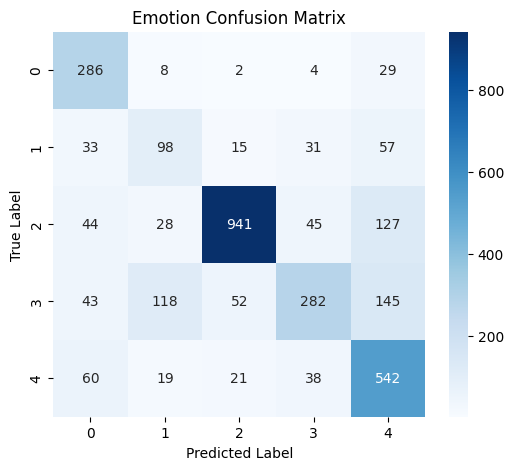

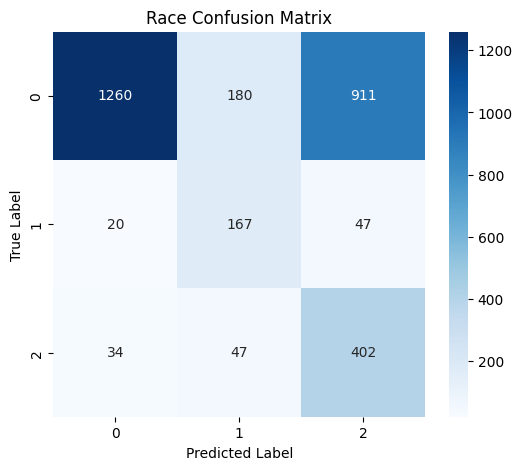

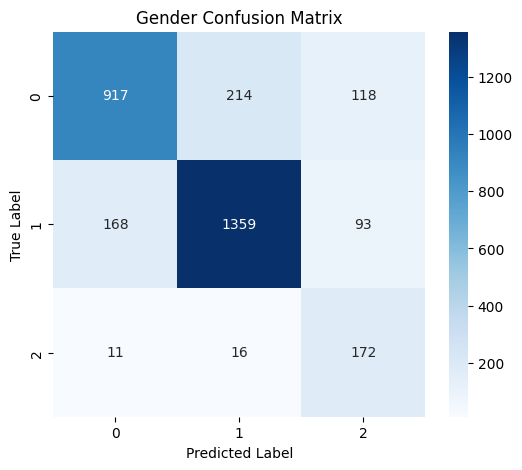

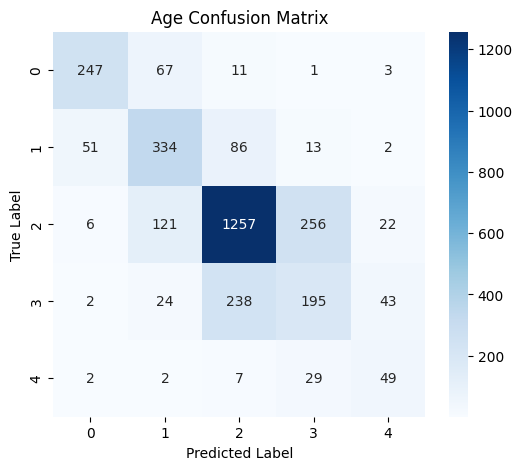

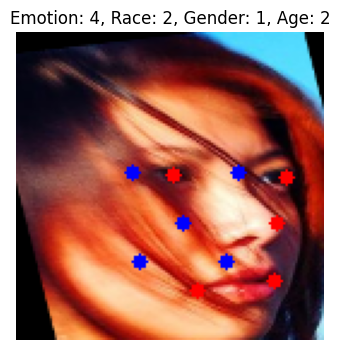

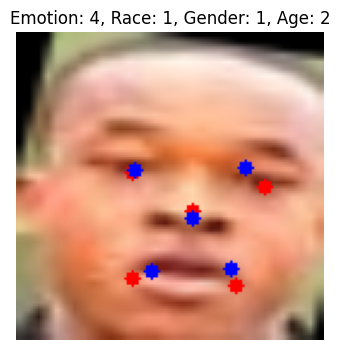

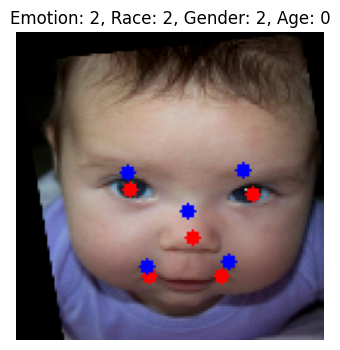

In [35]:
predictions, target = evaluate_model(model, test_loader, device)
eval_metrics = compute_metrics(predictions, target)
for key, value in eval_metrics.items():
    if not key.endswith('_confusion_matrix'):
        print(f"{key}: {value:.4f}" if isinstance(value, (float, np.floating)) else f"{key}: {value}")

for task in ['emotion', 'race', 'gender', 'age']:
    cm = eval_metrics[f'{task}_confusion_matrix']
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{task.capitalize()} Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()
show_batch_images_with_landmarks(val_loader, model, device=device, num_images=3, figsize=(4, 4))

#### att3

In [41]:
import importlib

import f4_model
importlib.reload(f4_model)
from f4_model import *

In [48]:

model, optimizer = initialize_model(Face_v3, device=device, lr=1e-3)
emotion_weights = compute_class_weights(train_df, 'emotion').to(device)
race_weights    = compute_class_weights(train_df, 'race').to(device)
gender_weights  = compute_class_weights(train_df, 'gender').to(device)
age_weights     = compute_class_weights(train_df, 'age').to(device)
losses = {
    'landmarks': nn.MSELoss(),  # regression, unweighted
    'emotion': nn.CrossEntropyLoss(weight=emotion_weights),
    'race': nn.CrossEntropyLoss(weight=race_weights),
    'gender': nn.CrossEntropyLoss(weight=gender_weights),
    'age': nn.CrossEntropyLoss(weight=age_weights)
}

In [49]:
name = f'face_multitask_v3_att3_{int(time.time())}'

In [ ]:
loss_weights = {
    'landmarks': 1.0,
    'emotion': 1.3, 
    'race': 1.2,
    'gender': 1.0,
    'age': 1
}
hist1 = train_model(
    model, {'train': train_loader, 'val': val_loader},
    optimizer, losses, name=f'{name}',
    device=device,
    loss_weights=loss_weights,
    num_epochs=35)
torch.save(model, f'{name}.pth')

Epoch 1/35


train: 100%|██████████| 346/346 [00:43<00:00,  7.95it/s]


train Losses: landmarks: 0.0092, emotion: 2.0799, race: 2.1039, gender: 1.0562, age: 2.2006


val: 100%|██████████| 39/39 [00:22<00:00,  1.74it/s]


val Losses: landmarks: 0.0080, emotion: 2.0665, race: 2.0326, gender: 1.0450, age: 2.2138
Epoch 2/35


...

val Losses: landmarks: 0.0075, emotion: 1.1620, race: 1.2002, gender: 0.6726, age: 1.3338
Epoch 35/35


train: 100%|██████████| 346/346 [00:37<00:00,  9.17it/s]


train Losses: landmarks: 0.0076, emotion: 1.0721, race: 0.8859, gender: 0.5167, age: 0.9414


val: 100%|██████████| 39/39 [00:20<00:00,  1.91it/s]

val Losses: landmarks: 0.0074, emotion: 1.3417, race: 1.2664, gender: 0.4958, age: 1.0962


emotion - y_pred shape: (3068,), y_true shape: (3068,)
race - y_pred shape: (3068,), y_true shape: (3068,)
gender - y_pred shape: (3068,), y_true shape: (3068,)
age - y_pred shape: (3068,), y_true shape: (3068,)
landmarks_mse: 0.0074
emotion_acc: 0.7008
emotion_f1: 0.7000
emotion_precision: 0.7304
emotion_recall: 0.7008
race_acc: 0.7174
race_f1: 0.7457
race_precision: 0.8224
race_recall: 0.7174
gender_acc: 0.7725
gender_f1: 0.7803
gender_precision: 0.8072
gender_recall: 0.7725
age_acc: 0.6444
age_f1: 0.6595
age_precision: 0.6983
age_recall: 0.6444


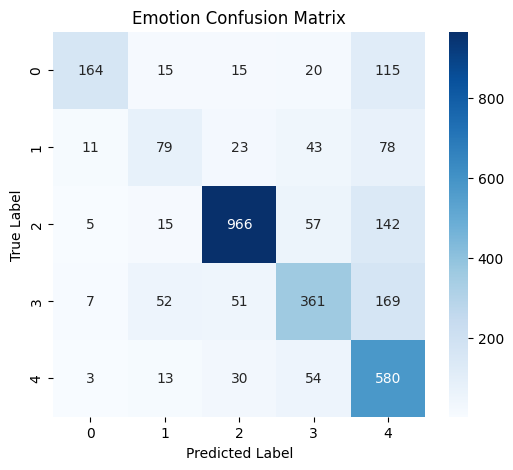

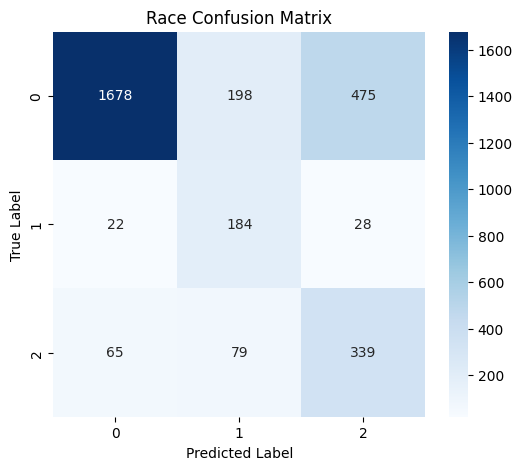

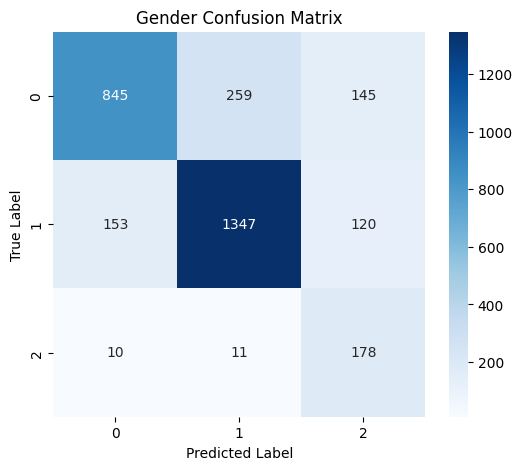

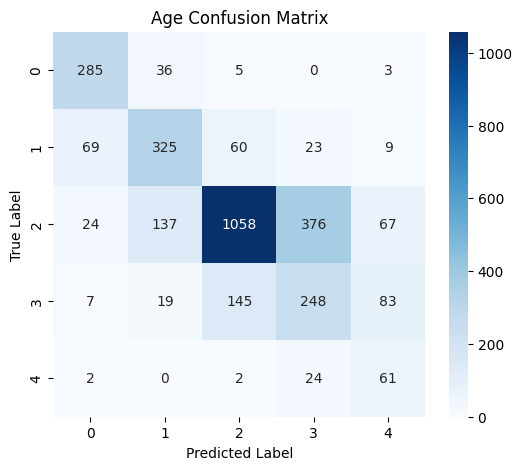

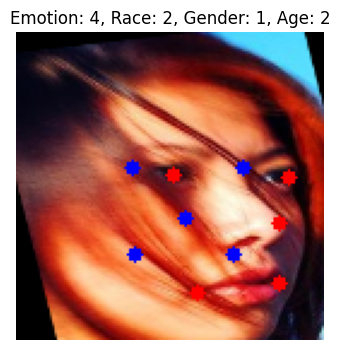

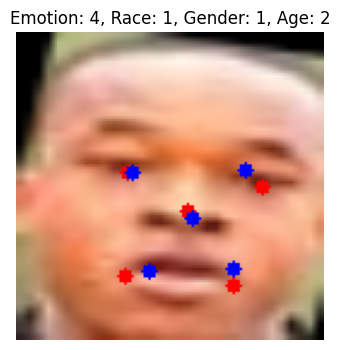

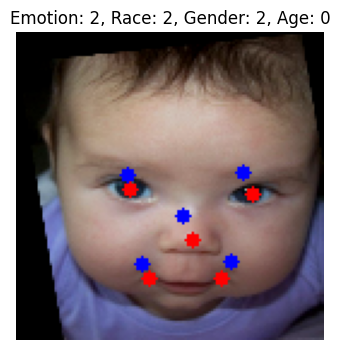

In [51]:
predictions, target = evaluate_model(model, test_loader, device)
eval_metrics = compute_metrics(predictions, target)
for key, value in eval_metrics.items():
    if not key.endswith('_confusion_matrix'):
        print(f"{key}: {value:.4f}" if isinstance(value, (float, np.floating)) else f"{key}: {value}")

for task in ['emotion', 'race', 'gender', 'age']:
    cm = eval_metrics[f'{task}_confusion_matrix']
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{task.capitalize()} Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()
show_batch_images_with_landmarks(val_loader, model, device=device, num_images=3, figsize=(4, 4))